In [2]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv('student_performance_raw.csv')

# cek bentuk data
print("shape:", df.shape)
print("\n5 data pertama:")
df.head()

shape: (2392, 15)

5 data pertama:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [3]:
# informasi dasar dataset
print("info dataset:")
print(df.info())
print("\nstatistik deskriptif:")
df.describe()

info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB
None

stat

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


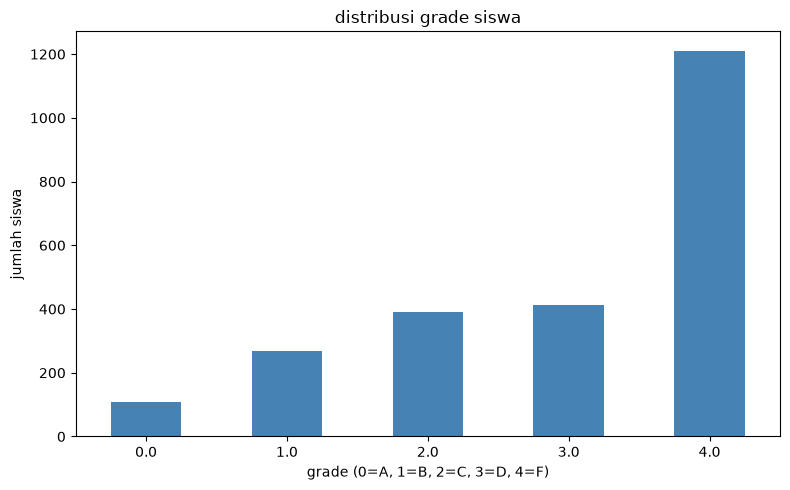

missing values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

jumlah duplikat: 0


In [4]:
# cek distribusi target
plt.figure(figsize=(8, 5))
grade_labels = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}
df['GradeClass'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('distribusi grade siswa')
plt.xlabel('grade (0=A, 1=B, 2=C, 3=D, 4=F)')
plt.ylabel('jumlah siswa')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# cek missing values
print("missing values:")
print(df.isnull().sum())

# cek duplikat
print(f"\njumlah duplikat: {df.duplicated().sum()}")

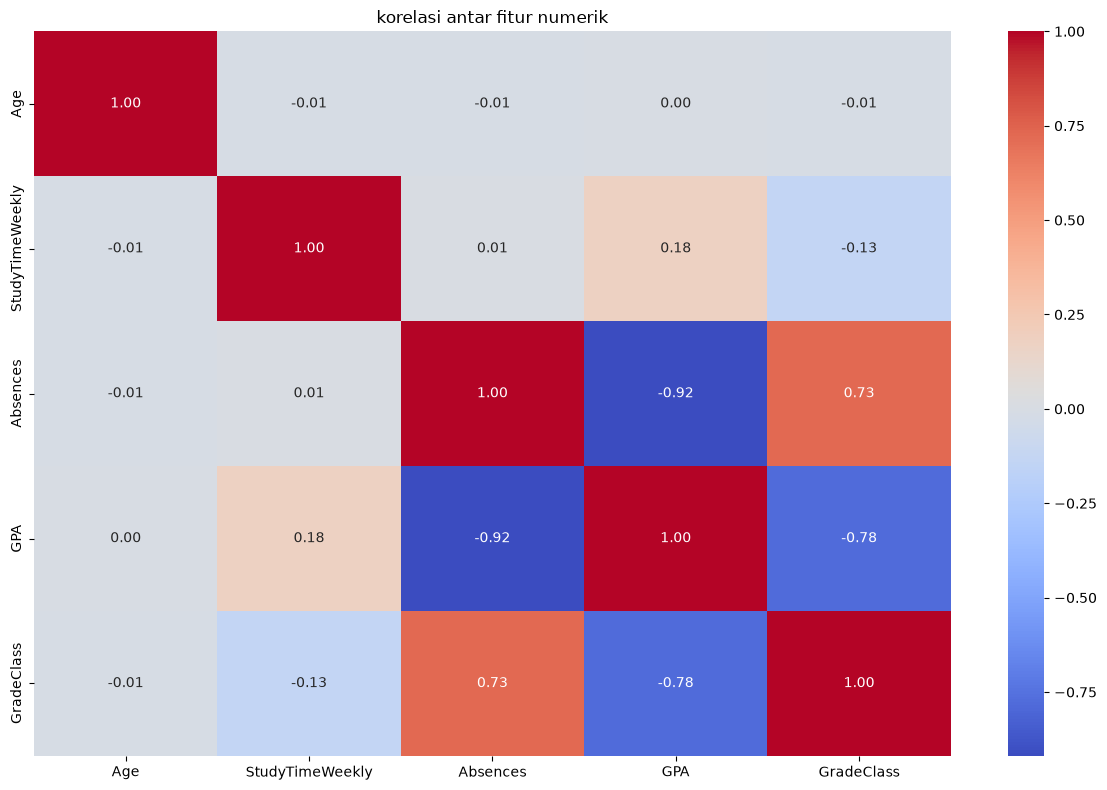

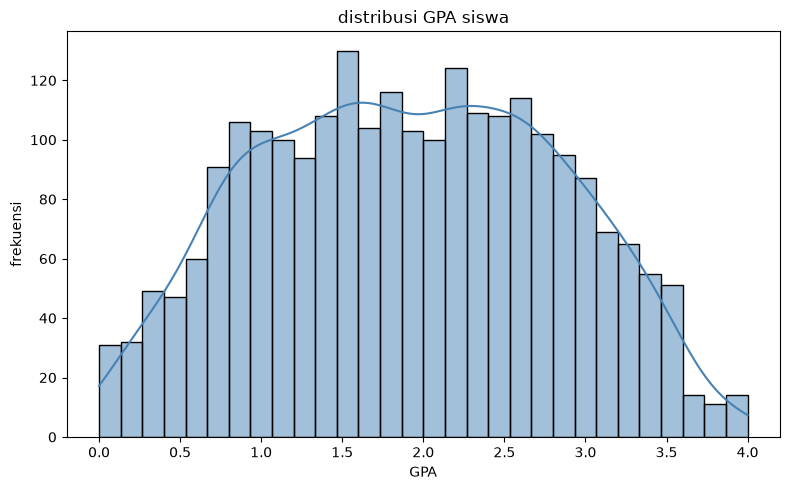

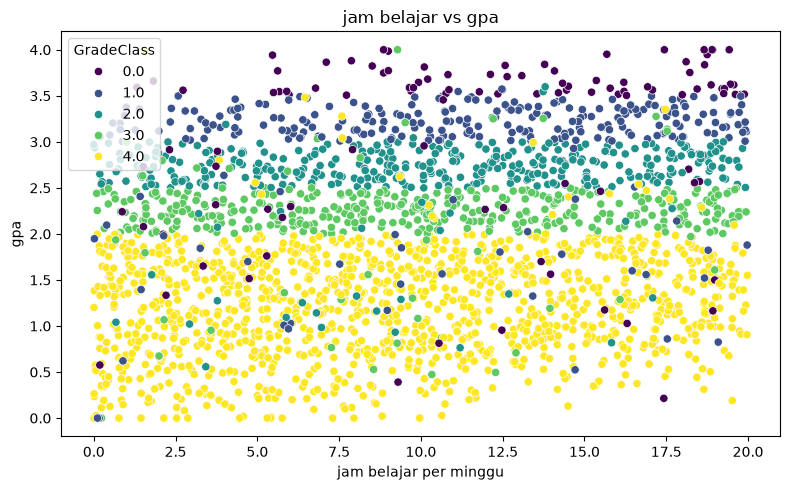

In [9]:
# heatmap korelasi antar fitur numerik
plt.figure(figsize=(12, 8))
numeric_cols = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA', 'GradeClass']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('korelasi antar fitur numerik')
plt.tight_layout()
plt.show()

# distribusi GPA
plt.figure(figsize=(8, 5))
sns.histplot(df['GPA'], bins=30, kde=True, color='steelblue')
plt.title('distribusi GPA siswa')
plt.xlabel('GPA')
plt.ylabel('frekuensi')
plt.tight_layout()
plt.show()

# hubungan jam belajar vs GPA
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='StudyTimeWeekly', y='GPA', hue='GradeClass', palette='viridis')
plt.title('jam belajar vs gpa')
plt.xlabel('jam belajar per minggu')
plt.ylabel('gpa')
plt.tight_layout()
plt.show()

In [10]:
# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# hapus kolom yang tidak diperlukan
df_clean = df.drop(columns=['StudentID'])

# pisahkan fitur dan target
X = df_clean.drop(columns=['GradeClass'])
y = df_clean['GradeClass'].astype(int)

# split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scaling fitur numerik
scaler = StandardScaler()
num_cols = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("ukuran data train:", X_train.shape)
print("ukuran data test:", X_test.shape)
print("\ndistribusi kelas (train):")
print(y_train.value_counts().sort_index())

# simpan hasil preprocessing
import os
os.makedirs('student_performance_preprocessing', exist_ok=True)

X_train_out = X_train.copy()
X_train_out['GradeClass'] = y_train.values
X_train_out.to_csv('student_performance_preprocessing/train.csv', index=False)

X_test_out = X_test.copy()
X_test_out['GradeClass'] = y_test.values
X_test_out.to_csv('student_performance_preprocessing/test.csv', index=False)

print("\ndata preprocessing berhasil disimpan!")

ukuran data train: (1913, 13)
ukuran data test: (479, 13)

distribusi kelas (train):
GradeClass
0     86
1    215
2    313
3    331
4    968
Name: count, dtype: int64

data preprocessing berhasil disimpan!


In [11]:
# simpan scaler
import pickle

with open('student_performance_preprocessing/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("scaler berhasil disimpan!")
print("\nstruktur folder preprocessing:")
for f in os.listdir('student_performance_preprocessing'):
    print(f"  {f}")

scaler berhasil disimpan!

struktur folder preprocessing:
  scaler.pkl
  test.csv
  train.csv
